# DINOv3 for Image Classification and Object Detection

**A hands-on tutorial for students**

In this notebook we will learn how to use **DINOv3** (Meta AI, 2025), a state-of-the-art self-supervised Vision Transformer, for two classic computer vision tasks:

1. **Image Classification** — predicting a single label for an entire image.
2. **Object Detection** — predicting bounding boxes and labels for objects within an image.

We will use the smallest version, **DINOv3-Small (ViT-S/16, ~21M parameters)**, so the examples run quickly even on modest hardware.

---

## Learning objectives

By the end of this notebook you will understand:

- What a **vision foundation model** is and why DINOv3 is useful.
- The difference between a **backbone** and a **task-specific head**.
- How to perform **off-the-shelf inference** (no training required).
- How to train classification and detection **heads** while keeping the backbone **frozen** (a strategy called **linear probing**).
- How to evaluate the trained model.

---

## Key concept: backbone vs. head

DINOv3 by itself is a **feature extractor** (the *backbone*). It takes an image and outputs a rich vector representation. It does **not** know about cats, dogs, or bounding boxes.

To make it useful for a specific task we attach a small neural network on top — the *head*:

| Task | Head |
|------|------|
| Classification | A linear layer mapping features → class scores |
| Detection | A lightweight network mapping features → bounding boxes + class scores |

When we **freeze the backbone**, only the head's weights are updated during training. This is fast, requires less data, and preserves the high-quality features DINOv3 learned from 1.7 billion images.


## 1. Setup and dependencies

We will use:

- **PyTorch** — deep learning framework.
- **Hugging Face Transformers** (≥ 4.56) — provides the DINOv3 weights.
- **torchvision** — small datasets (CIFAR-10) and image utilities.
- **Pillow** — image loading.
- **matplotlib** — visualization.

Run the cell below once to install everything.


In [1]:
# Install required libraries (uncomment if running for the first time)
# !pip install -q torch torchvision transformers>=4.56.0 pillow matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
from torchvision.datasets import CIFAR10
from transformers import AutoModel, AutoImageProcessor
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO
from huggingface_hub import login
from dotenv import load_dotenv
import os

load_dotenv()
login(token=os.getenv("HUGGING_FACE_TOKEN"))

# Use GPU if available, otherwise fall back to CPU.
# Pick the best available device. CUDA > MPS (Apple Silicon) > CPU.
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")


/Users/adan.mora/Desktop/code/university/computer-vision-course/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## 2. Loading DINOv3-Small

We load the pretrained DINOv3-Small backbone from the Hugging Face Hub.

- `AutoImageProcessor` handles image preprocessing (resizing, normalization).
- `AutoModel` loads the actual transformer weights.

The backbone is set to **evaluation mode** (`.eval()`) which disables dropout and batch-norm updates — important for inference and for frozen-backbone training.


In [2]:
# Model ID on Hugging Face. DINOv3-Small uses patch size 16.
MODEL_ID = "facebook/dinov3-vits16-pretrain-lvd1689m"

# Image processor: handles resizing + ImageNet normalization automatically
processor = AutoImageProcessor.from_pretrained(MODEL_ID)

# Backbone: the Vision Transformer that produces feature vectors
backbone = AutoModel.from_pretrained(MODEL_ID).to(device)
backbone.eval()

# Inspect the model
total_params = sum(p.numel() for p in backbone.parameters())
hidden_dim = backbone.config.hidden_size
print(f"Total parameters: {total_params/1e6:.1f}M")
print(f"Hidden dimension (feature size): {hidden_dim}")


Loading weights: 100%|██████████| 211/211 [00:00<00:00, 7171.49it/s]

Total parameters: 21.6M
Hidden dimension (feature size): 384


### What does the backbone actually output?

Given an input image, DINOv3 returns a sequence of feature vectors:

- **CLS token** — a single vector summarizing the whole image. We use this for **classification**.
- **Patch tokens** — one vector per image patch (e.g. 196 patches for a 224×224 image with patch size 16). These keep spatial information and are useful for **detection** and **segmentation**.

Let's verify this with a dummy image.


In [3]:
# Build a dummy 224x224 RGB image
dummy = Image.new("RGB", (224, 224), color=(128, 128, 128))
inputs = processor(images=dummy, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = backbone(**inputs)

# last_hidden_state has shape [batch, num_tokens, hidden_dim]
print(f"Output shape: {outputs.last_hidden_state.shape}")
print(f"  - Token 0       -> CLS token (global image representation)")
print(f"  - Tokens 1..N   -> Patch tokens (spatial features)")


Output shape: torch.Size([1, 201, 384])
  - Token 0       -> CLS token (global image representation)
  - Tokens 1..N   -> Patch tokens (spatial features)


## 3. Off-the-shelf inference (no training)

Before doing any training, let's see what DINOv3 can do **out of the box**.

DINOv3 was trained without labels, so it does **not** directly predict class names. However, its features are so semantically rich that two images of the same object will have similar feature vectors.

We will use this property to perform **nearest-neighbour image retrieval**: given a query image, we find which images in a reference set are most similar.

This is a great way to demonstrate the power of a frozen foundation model — **zero training required**.


In [4]:
def extract_features(image, model=backbone, proc=processor):
    """Extract the CLS feature vector for a single PIL image."""
    inputs = proc(images=image, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    # CLS token is at position 0
    cls = outputs.last_hidden_state[:, 0]
    # Normalize so cosine similarity = dot product
    cls = F.normalize(cls, dim=-1)
    return cls.cpu()


def inference_similarity(query_image, reference_images, top_k=3):
    """Find the top_k most similar reference images to the query.

    Args:
        query_image: a PIL image
        reference_images: list of PIL images
        top_k: how many neighbours to return
    Returns:
        list of (index, similarity_score) tuples sorted from most to least similar
    """
    q_feat = extract_features(query_image)
    ref_feats = torch.cat([extract_features(img) for img in reference_images], dim=0)
    similarities = (q_feat @ ref_feats.T).squeeze(0)  # cosine similarity
    top = torch.topk(similarities, k=min(top_k, len(reference_images)))
    return list(zip(top.indices.tolist(), top.values.tolist()))


### Try it on real images

We load a small batch of **COCO 2017** images (the same animal subset we'll use for detection in §5) and use one image as a query: DINOv3 should rank visually/semantically similar animals as the closest neighbours, *without any training on COCO labels*.

The first run downloads the subset via FiftyOne (~minutes); subsequent runs hit the local cache.

Loaded cached 'coco_small_dinov3_animals' (400 samples).
Indexed 400 images.
Class distribution:
     cat: 104
     dog: 100
    bird: 67
   horse: 82
   zebra: 47
    bear: 0

Computing DINOv3 features for 400 images...
  gallery_feats: torch.Size([400, 384])


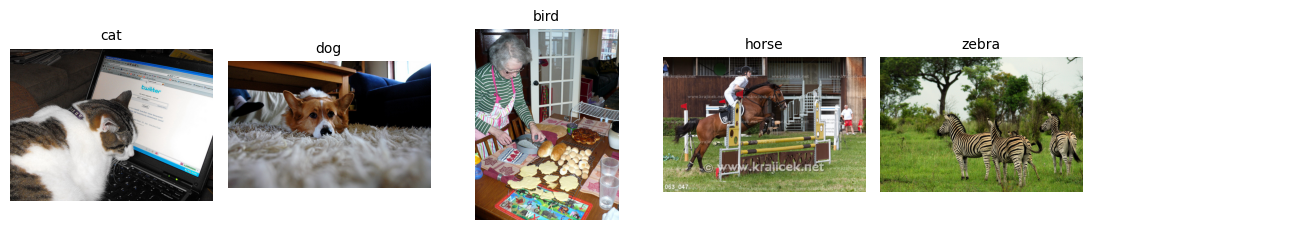

In [5]:
import random
from collections import Counter
import fiftyone as fo
import fiftyone.zoo as foz

# Reuse the same COCO subset name as §5 so the download is shared.
RETRIEVAL_CLASSES = ["cat", "dog", "bird", "horse", "zebra", "bear"]
RETRIEVAL_DATASET_NAME = "coco_small_dinov3_animals"

if RETRIEVAL_DATASET_NAME in fo.list_datasets():
    _ds = fo.load_dataset(RETRIEVAL_DATASET_NAME)
    print(f"Loaded cached '{RETRIEVAL_DATASET_NAME}' ({len(_ds)} samples).")
else:
    _ds = foz.load_zoo_dataset(
        "coco-2017",
        split="validation",
        label_types=["detections"],
        classes=RETRIEVAL_CLASSES,
        max_samples=400,
        only_matching=True,
        shuffle=True,
        seed=0,
        dataset_name=RETRIEVAL_DATASET_NAME,
    )
    _ds.persistent = True
    print(f"Downloaded {len(_ds)} samples into '{RETRIEVAL_DATASET_NAME}'.")


def _primary_class(sample, allowed):
    """Most-common allowed-class label in a FiftyOne sample's detections."""
    for fname in ("detections", "ground_truth"):
        if sample.has_field(fname):
            field = sample[fname]
            if field is not None and field.detections:
                labels = [d.label for d in field.detections if d.label in allowed]
                if labels:
                    return Counter(labels).most_common(1)[0][0]
    return None


# Index the WHOLE dataset (not just a small balanced gallery).
allowed = set(RETRIEVAL_CLASSES)
all_samples = list(_ds)
random.seed(42); random.shuffle(all_samples)

sample_paths, image_labels = [], []
for s in all_samples:
    cls = _primary_class(s, allowed)
    if cls is None:
        continue
    sample_paths.append(s.filepath)
    image_labels.append(cls)

print(f"Indexed {len(sample_paths)} images.")
print("Class distribution:")
counts = Counter(image_labels)
for c in RETRIEVAL_CLASSES:
    print(f"  {c:>6}: {counts.get(c, 0)}")


# Compute DINOv3 features for every indexed image, in batches (one-time cost).
@torch.no_grad()
def _batch_features(paths, batch_size=16):
    backbone.eval()
    feats = []
    for i in range(0, len(paths), batch_size):
        imgs = [Image.open(p).convert("RGB") for p in paths[i:i + batch_size]]
        inp = processor(images=imgs, return_tensors="pt").to(device)
        out = backbone(**inp).last_hidden_state[:, 0]
        feats.append(F.normalize(out, dim=-1).cpu())
    return torch.cat(feats, dim=0)


print(f"\nComputing DINOv3 features for {len(sample_paths)} images...")
gallery_feats = _batch_features(sample_paths)
print(f"  gallery_feats: {gallery_feats.shape}")

# Quick preview — one example per class
fig, axes = plt.subplots(1, len(RETRIEVAL_CLASSES),
                         figsize=(2.2 * len(RETRIEVAL_CLASSES), 2.4))
for ax, cls in zip(axes, RETRIEVAL_CLASSES):
    idx = next((i for i, lbl in enumerate(image_labels) if lbl == cls), None)
    if idx is not None:
        ax.imshow(Image.open(sample_paths[idx]).convert("RGB"))
        ax.set_title(cls, fontsize=10)
    ax.axis("off")
plt.tight_layout(); plt.show()

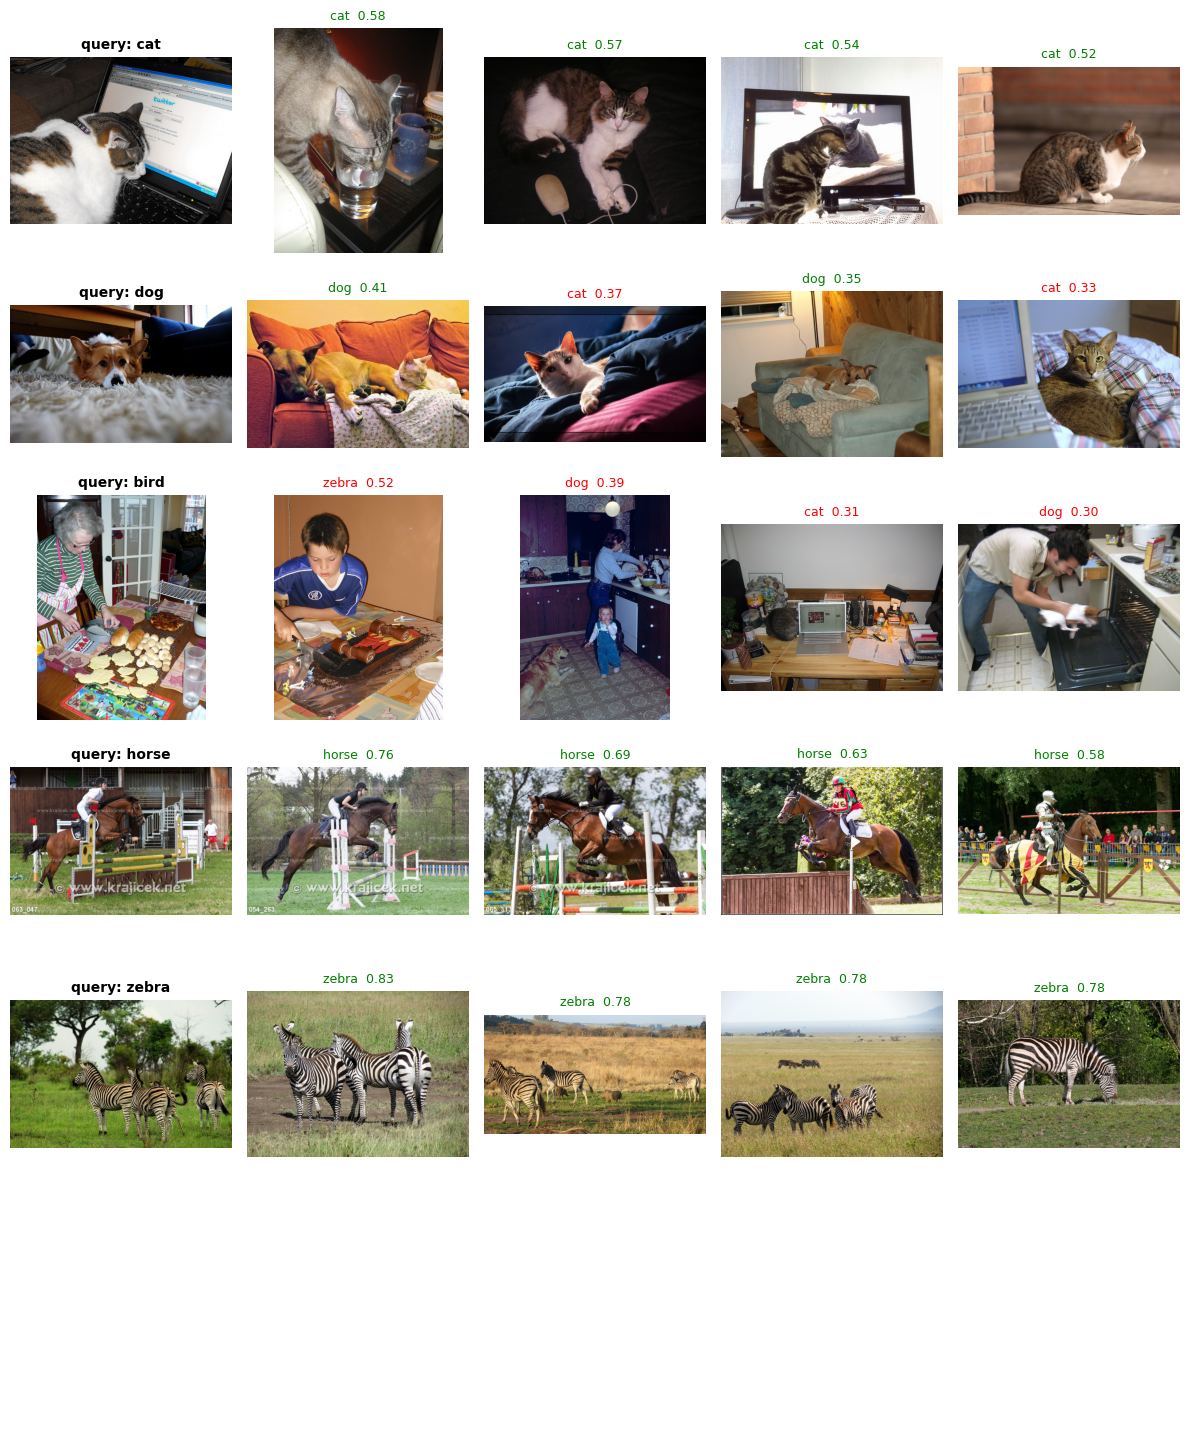

Green title = same class as query, red = different class.


In [6]:
# One query per class. For each class, pick its first image in the index
# and retrieve the top-K most similar images from the WHOLE dataset.
TOP_K = 4

# First indexed image of each class is our query
class_to_query_idx = {}
for i, lbl in enumerate(image_labels):
    class_to_query_idx.setdefault(lbl, i)

n_rows = len(RETRIEVAL_CLASSES)
fig, axes = plt.subplots(n_rows, 1 + TOP_K,
                         figsize=(2.4 * (1 + TOP_K), 2.4 * n_rows))

for row, cls in enumerate(RETRIEVAL_CLASSES):
    qi = class_to_query_idx.get(cls)
    if qi is None:
        for ax in axes[row]:
            ax.axis("off")
        continue

    # Cosine similarity against the whole dataset (features are L2-normalized)
    sims = (gallery_feats[qi:qi+1] @ gallery_feats.T).squeeze(0).clone()
    sims[qi] = -1.0  # mask the query itself
    top = torch.topk(sims, k=TOP_K)

    ax_q = axes[row, 0]
    ax_q.imshow(Image.open(sample_paths[qi]).convert("RGB")); ax_q.axis("off")
    ax_q.set_title(f"query: {cls}", fontsize=10, fontweight="bold")

    for col, (idx, sim) in enumerate(zip(top.indices.tolist(), top.values.tolist()), start=1):
        ax = axes[row, col]
        ax.imshow(Image.open(sample_paths[idx]).convert("RGB")); ax.axis("off")
        color = "green" if image_labels[idx] == cls else "red"
        ax.set_title(f"{image_labels[idx]}  {sim:.2f}", fontsize=9, color=color)

plt.tight_layout(); plt.show()
print("Green title = same class as query, red = different class.")

## 4. Image classification with a frozen backbone

Now we will train a real classifier using DINOv3 as a **frozen feature extractor**.

### The strategy ("linear probing")

1. Pass each image through the frozen DINOv3 backbone → get the CLS feature vector.
2. Feed that vector into a single `nn.Linear` layer that maps `hidden_dim → num_classes`.
3. Train **only** the linear layer with cross-entropy loss.

Because we only train one tiny layer (~3,840 parameters for CIFAR-10), training is extremely fast and works with very little data.

### The dataset

We will use **CIFAR-10**, a small dataset of 32×32 images across 10 categories (airplane, automobile, bird, cat, …). To keep training quick for class, we will use only **a small subset**.


In [7]:
# Build a small CIFAR-10 subset
CIFAR_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                 'dog', 'frog', 'horse', 'ship', 'truck']

# The processor expects PIL images, but CIFAR returns tensors by default.
# We keep a minimal transform that yields PIL images for the processor.
to_pil = T.Compose([T.ToPILImage()])

# Download CIFAR-10 (small ~170 MB)
full_train = CIFAR10(root="./data", train=True, download=True)
full_test  = CIFAR10(root="./data", train=False, download=True)

# Take a small subset for pedagogy: 50% train / 50% test
import random
random.seed(0)
train_idx = random.sample(range(len(full_train)), 5000)
test_idx  = random.sample(range(len(full_test)), 1500)

train_subset = Subset(full_train, train_idx)
test_subset  = Subset(full_test,  test_idx)
print(f"Train subset size: {len(train_subset)}")
print(f"Test  subset size: {len(test_subset)}")


/Users/adan.mora/Desktop/code/university/computer-vision-course/venv/lib/python3.13/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train subset size: 5000
Test  subset size: 1500


### Pre-compute features (a big speed-up!)

Since the backbone is frozen, running it on the same image every epoch is wasteful. A common trick is to **pre-compute all features once**, then train the linear head on the cached features.

This turns training into a tiny logistic-regression problem that finishes in seconds.


In [8]:
@torch.no_grad()
def compute_features(dataset, batch_size=32):
    """Run DINOv3 on every image in the dataset and return (features, labels)."""
    backbone.eval()
    feats, labels = [], []
    for i in range(0, len(dataset), batch_size):
        batch = [dataset[j] for j in range(i, min(i + batch_size, len(dataset)))]
        pil_imgs = [img for img, _ in batch]
        lbls     = [lbl for _, lbl in batch]
        inputs = processor(images=pil_imgs, return_tensors="pt").to(device)
        out = backbone(**inputs).last_hidden_state[:, 0]   # CLS only
        feats.append(out.cpu())
        labels.extend(lbls)
    return torch.cat(feats, dim=0), torch.tensor(labels)


print("Computing train features...")
train_feats, train_labels = compute_features(train_subset)
print(f"  shape: {train_feats.shape}")

print("Computing test features...")
test_feats, test_labels = compute_features(test_subset)
print(f"  shape: {test_feats.shape}")


Computing train features...
  shape: torch.Size([5000, 384])
Computing test features...
  shape: torch.Size([1500, 384])


### Define the classifier and the training loop

The classifier is the simplest possible: a single linear layer. The training function below is the **frozen-backbone training routine** you can re-use for any classification dataset.


In [9]:
class LinearClassifier(nn.Module):
    """Single linear layer on top of DINOv3 CLS features."""
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.fc = nn.Linear(in_dim, num_classes)

    def forward(self, x):
        return self.fc(x)


def train_classifier(features, labels, num_classes, epochs=20, lr=1e-3, batch_size=64):
    """Train a linear classifier on pre-computed (frozen) backbone features.

    The backbone is NEVER touched here — we only update the head.
    """
    model = LinearClassifier(features.shape[1], num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    features, labels = features.to(device), labels.to(device)
    n = features.shape[0]

    for epoch in range(epochs):
        model.train()
        # Shuffle the data each epoch
        perm = torch.randperm(n)
        total_loss = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            x, y = features[idx], labels[idx]

            logits = model(x)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
        avg = total_loss / n
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  Epoch {epoch+1:>2}/{epochs}  loss={avg:.4f}")
    return model


@torch.no_grad()
def evaluate_classifier(model, features, labels):
    model.eval()
    features, labels = features.to(device), labels.to(device)
    preds = model(features).argmax(dim=-1)
    acc = (preds == labels).float().mean().item()
    return acc


In [10]:
# Train!
classifier = train_classifier(train_feats, train_labels,
                              num_classes=10, epochs=20)

# Evaluate
train_acc = evaluate_classifier(classifier, train_feats, train_labels)
test_acc  = evaluate_classifier(classifier, test_feats,  test_labels)
print(f"\nTrain accuracy: {train_acc*100:.2f}%")
print(f"Test  accuracy: {test_acc*100:.2f}%")


  Epoch  1/20  loss=1.3016
  Epoch  5/20  loss=0.2248
  Epoch 10/20  loss=0.1408
  Epoch 15/20  loss=0.1064
  Epoch 20/20  loss=0.0857

Train accuracy: 98.20%
Test  accuracy: 95.53%


### Detailed evaluation: per-class accuracy + confusion matrix

Overall accuracy hides a lot. Two models with the same number can fail very differently — one might be perfect on 9 classes and 0% on the 10th. We add:

- **Per-class accuracy** — recall for each class (what fraction of true `cat` images did we predict as `cat`).
- **Confusion matrix** — rows = true class, columns = predicted class. The diagonal is correct predictions; off-diagonal cells reveal which classes get mistaken for which.

       class     acc     n
    airplane   95.3%   150
  automobile   98.1%   157
        bird   92.5%   146
         cat   93.8%   145
        deer   94.6%   148
         dog   90.8%   141
        frog   97.7%   171
       horse   98.5%   135
        ship   96.2%   160
       truck   97.3%   147


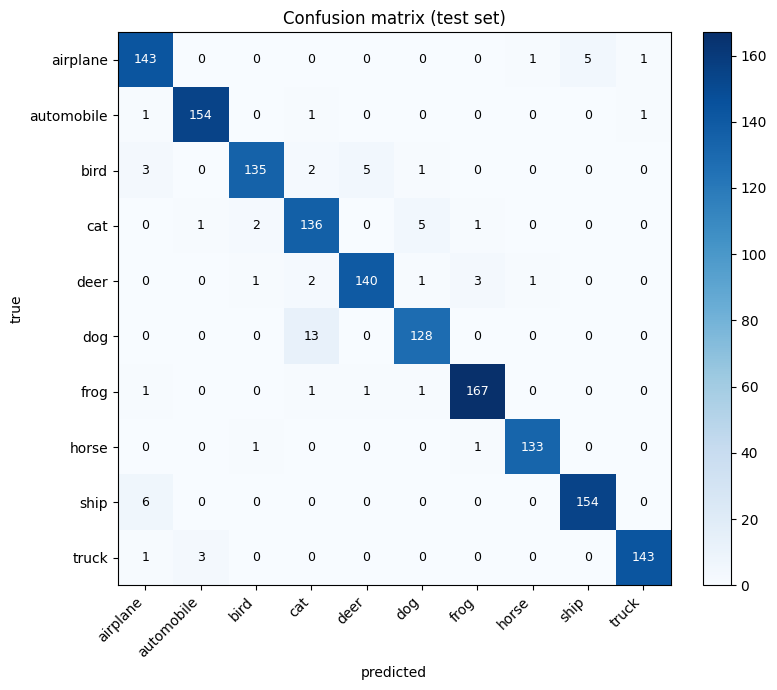

In [11]:
@torch.no_grad()
def detailed_classifier_eval(head, features, labels, class_names):
    head.eval()
    preds = head(features.to(device)).argmax(dim=-1).cpu().numpy()
    y = labels.numpy()
    n = len(class_names)

    # Per-class accuracy (recall)
    print(f"{'class':>12}  {'acc':>6}  {'n':>4}")
    for c in range(n):
        mask = y == c
        if mask.sum() == 0:
            print(f"{class_names[c]:>12}    n/a     0")
            continue
        acc = (preds[mask] == c).mean()
        print(f"{class_names[c]:>12}  {acc*100:5.1f}%  {mask.sum():4d}")

    # Confusion matrix
    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y, preds):
        cm[t, p] += 1

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(n)); ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticks(range(n)); ax.set_yticklabels(class_names)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title("Confusion matrix (test set)")
    thresh = cm.max() / 2 if cm.max() > 0 else 1
    for i in range(n):
        for j in range(n):
            color = "white" if cm[i, j] > thresh else "black"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color, fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046)
    plt.tight_layout(); plt.show()


detailed_classifier_eval(classifier, test_feats, test_labels, CIFAR_CLASSES)

### Inspect predictions

Let's look at a few predictions to see how the model behaves.


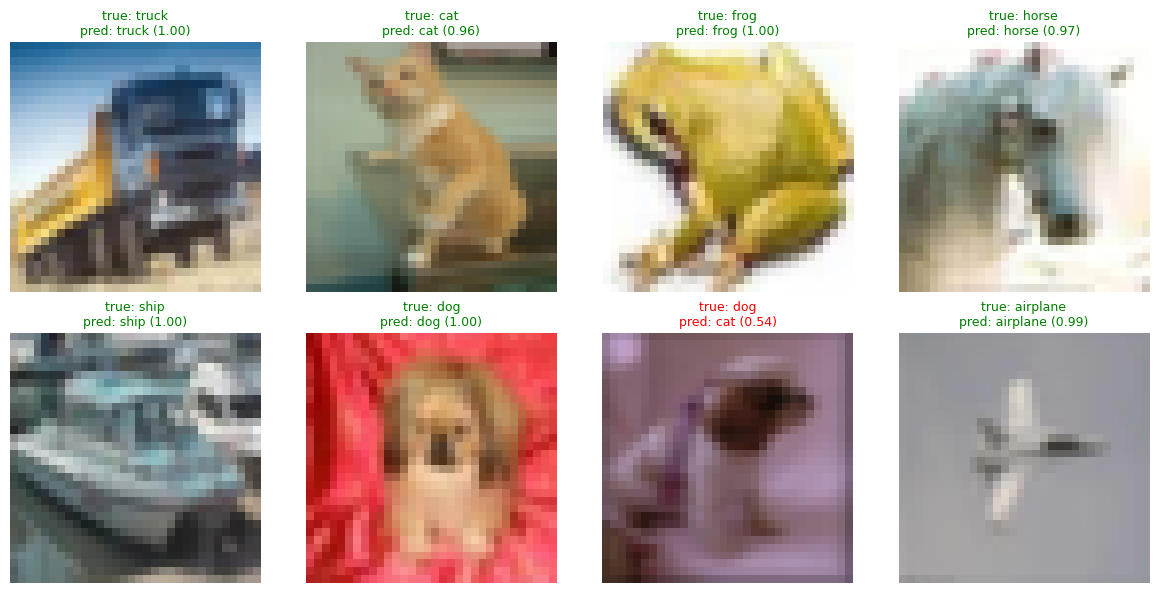

In [12]:
@torch.no_grad()
def predict_image(pil_image, head=classifier):
    """Run the full pipeline (backbone + head) on a single PIL image."""
    inputs = processor(images=pil_image, return_tensors="pt").to(device)
    feat = backbone(**inputs).last_hidden_state[:, 0]
    logits = head(feat)
    probs = F.softmax(logits, dim=-1).cpu().numpy()[0]
    pred_idx = int(probs.argmax())
    return CIFAR_CLASSES[pred_idx], probs[pred_idx]


# Show 8 random test images with predictions
sample_idx = random.sample(range(len(test_subset)), 8)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, idx in zip(axes.flat, sample_idx):
    img, true_lbl = test_subset[idx]
    pred_name, conf = predict_image(img)
    true_name = CIFAR_CLASSES[true_lbl]
    color = "green" if pred_name == true_name else "red"
    ax.imshow(img)
    ax.set_title(f"true: {true_name}\npred: {pred_name} ({conf:.2f})",
                 color=color, fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 5. Object detection with Faster R-CNN

We replace the toy single-shape detector with a real **Faster R-CNN** trained on a small slice of **COCO 2017**. DINOv3 stays frozen — only the detection-specific layers learn.

### What Faster R-CNN predicts

For each image:

1. A **set of bounding boxes** (variable number per image)
2. A **class label** for each box
3. A **confidence score** for each detection

The architecture is:

- **Region Proposal Network (RPN)** scans the feature map and proposes candidate boxes.
- **ROI Align** crops a fixed-size feature for each proposal.
- A **box head** refines the box and predicts a class.

(Mask R-CNN = Faster R-CNN + an extra mask head. We're dropping that head here for a pure detection task.)

### Wiring DINOv3 (a ViT) into a detector

Faster R-CNN was originally designed for backbones with a Feature Pyramid Network (multiple scales). A ViT only gives us **one** scale. We adapt by:

1. Taking DINOv3's **patch tokens** (skipping the CLS + register tokens).
2. Reshaping them into a `[B, 384, H/16, W/16]` feature map.
3. Feeding that single feature map into `torchvision.models.detection.FasterRCNN`, configured with a **single-scale anchor generator**.

```
image (3 × 320 × 320)
   └── frozen DINOv3-Small (ViT-S/16)
         └── patches reshape → feature map (384 × 20 × 20)
                ├── RPN ──────────────────── proposes boxes
                └── ROI Align → box head ── class + refined box
```

This is a simplified stand-in for **ViTDet**, which builds a proper FPN from intermediate ViT blocks. Good enough for teaching, and the *frozen-backbone + task-specific heads* pattern carries straight over.

In [13]:
# Detection-specific imports (uncomment install if running for the first time)
# !pip install -q fiftyone pycocotools

import torchvision
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.transform import GeneralizedRCNNTransform
from torchvision.ops import MultiScaleRoIAlign
from torch.utils.data import DataLoader
from collections import OrderedDict

### A small COCO 2017 subset via FiftyOne

[FiftyOne](https://docs.voxel51.com/) lets us pull a curated slice of COCO instead of downloading all 18 GB. We grab **400 validation images** restricted to six animal classes (`cat`, `dog`, `bird`, `horse`, `zebra`, `bear`) with their bounding boxes, and split them 80 / 20 into train / val.

After the first run FiftyOne caches everything locally — re-running the cell is instant.

In [14]:
import fiftyone as fo
import fiftyone.zoo as foz

COCO_CLASSES = ["cat", "dog", "bird", "horse", "zebra", "bear"]

DATASET_NAME = "coco_small_dinov3_animals"
if DATASET_NAME in fo.list_datasets():
    fo_dataset = fo.load_dataset(DATASET_NAME)
    print(f"Loaded cached '{DATASET_NAME}' ({len(fo_dataset)} samples).")
else:
    fo_dataset = foz.load_zoo_dataset(
        "coco-2017",
        split="validation",
        label_types=["detections"],          # boxes only — no masks for Faster R-CNN
        classes=COCO_CLASSES,
        max_samples=400,
        only_matching=True,
        shuffle=True,
        seed=0,
        dataset_name=DATASET_NAME,
    )
    fo_dataset.persistent = True
    print(f"Downloaded {len(fo_dataset)} samples into '{DATASET_NAME}'.")

# 80 / 20 train / val split (deterministic)
all_samples = list(fo_dataset)
random.seed(0); random.shuffle(all_samples)
n_train = int(0.8 * len(all_samples))
train_samples = all_samples[:n_train]
val_samples   = all_samples[n_train:]
print(f"Train: {len(train_samples)} | Val: {len(val_samples)}")

Loaded cached 'coco_small_dinov3_animals' (400 samples).
Train: 320 | Val: 80


### A PyTorch Dataset that yields Faster R-CNN targets

`FasterRCNN.forward` expects each target, per image, in the form:

| key | shape | meaning |
|-----|-------|---------|
| `boxes`    | `[N, 4]` float | `[x1, y1, x2, y2]` in image pixels |
| `labels`   | `[N]` int64    | class index — **0 is reserved for background** |
| `image_id` | `[1]` int64    | arbitrary id (for evaluation only) |

The dataset below:

1. Resizes each image to a fixed **320 × 320** (a multiple of the ViT patch size 16, so the patch grid is exactly 20 × 20).
2. Converts FiftyOne's relative `[x, y, w, h]` bounding boxes to absolute `[x1, y1, x2, y2]` pixel coordinates in the resized image.
3. Drops empty or invalid annotations.

In [15]:
def _detections_of(sample):
    """Return the FiftyOne Detections list on a COCO sample (handles default field names)."""
    for fname in ("detections", "ground_truth"):
        if not sample.has_field(fname):
            continue
        f = sample[fname]
        if f is not None and getattr(f, "detections", None):
            return f.detections
    return []


class CocoDetectionDataset(torch.utils.data.Dataset):
    """FiftyOne COCO subset → (image_tensor, faster-rcnn target) pairs."""

    def __init__(self, fo_samples, class_names, img_size=320):
        self.samples = fo_samples
        self.class_to_idx = {name: i + 1 for i, name in enumerate(class_names)}  # 0 = background
        self.img_size = img_size

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample.filepath).convert("RGB")
        S = self.img_size
        img_t = T.ToTensor()(img.resize((S, S), Image.BILINEAR))  # [3, S, S] in [0, 1]

        boxes, labels = [], []
        for det in _detections_of(sample):
            if det.label not in self.class_to_idx:
                continue
            x_r, y_r, w_r, h_r = det.bounding_box
            if w_r <= 0 or h_r <= 0:
                continue
            x1, y1 = x_r * S, y_r * S
            x2, y2 = (x_r + w_r) * S, (y_r + h_r) * S
            if x2 - x1 < 1 or y2 - y1 < 1:
                continue
            boxes.append([x1, y1, x2, y2])
            labels.append(self.class_to_idx[det.label])

        if boxes:
            target = {
                "boxes":  torch.tensor(boxes,  dtype=torch.float32),
                "labels": torch.tensor(labels, dtype=torch.int64),
                "image_id": torch.tensor([idx]),
            }
        else:
            target = {
                "boxes":  torch.zeros((0, 4), dtype=torch.float32),
                "labels": torch.zeros((0,),   dtype=torch.int64),
                "image_id": torch.tensor([idx]),
            }
        return img_t, target


def collate_fn(batch):
    return list(zip(*batch))


IMG_SIZE = 320
train_ds = CocoDetectionDataset(train_samples, COCO_CLASSES, img_size=IMG_SIZE)
val_ds   = CocoDetectionDataset(val_samples,   COCO_CLASSES, img_size=IMG_SIZE)
train_loader = DataLoader(train_ds, batch_size=2, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=2, shuffle=False, collate_fn=collate_fn)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 160 | Val batches: 40


In [16]:
class DinoV3DetectionBackbone(nn.Module):
    """Wrap frozen DINOv3 as a single-scale backbone for torchvision FasterRCNN.

    Output: OrderedDict({"0": [B, hidden_dim, H/16, W/16]}).
    """
    def __init__(self, dino_model, hidden_dim, patch_size=16):
        super().__init__()
        self.dino = dino_model
        self.out_channels = hidden_dim
        self.patch_size = patch_size
        for p in self.dino.parameters():
            p.requires_grad = False
        self.dino.eval()

    def train(self, mode=True):
        # Always keep DINOv3 in eval mode regardless of the wrapper's mode.
        super().train(mode)
        self.dino.eval()
        return self

    def forward(self, x):
        B, _, H, W = x.shape
        with torch.no_grad():
            out = self.dino(pixel_values=x, interpolate_pos_encoding=True)
        tokens = out.last_hidden_state                       # [B, 1 + R + N, C]
        Hp, Wp = H // self.patch_size, W // self.patch_size
        # The last Hp*Wp tokens are the patch tokens — robust to CLS/register count.
        patches = tokens[:, -(Hp * Wp):, :]
        feat = patches.permute(0, 2, 1).reshape(B, self.out_channels, Hp, Wp)
        return OrderedDict([("0", feat)])


NUM_CLASSES = 1 + len(COCO_CLASSES)  # +1 for background
det_backbone = DinoV3DetectionBackbone(backbone, hidden_dim=hidden_dim).to(device)

# One feature map → one tuple of anchor sizes
anchor_generator = AnchorGenerator(
    sizes=((16, 32, 64, 128, 256),),
    aspect_ratios=((0.5, 1.0, 2.0),),
)
box_roi_pool = MultiScaleRoIAlign(featmap_names=["0"], output_size=7, sampling_ratio=2)

# DINOv3 was pretrained with ImageNet normalization → match that here.
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

frcnn = FasterRCNN(
    det_backbone,
    num_classes=NUM_CLASSES,
    rpn_anchor_generator=anchor_generator,
    box_roi_pool=box_roi_pool,
    image_mean=IMG_MEAN,
    image_std=IMG_STD,
    min_size=IMG_SIZE,
    max_size=IMG_SIZE,
).to(device)

# Force input transform to keep H, W divisible by the ViT patch size.
frcnn.transform = GeneralizedRCNNTransform(
    min_size=IMG_SIZE, max_size=IMG_SIZE,
    image_mean=IMG_MEAN, image_std=IMG_STD,
    size_divisible=16,
)

trainable = sum(p.numel() for p in frcnn.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in frcnn.parameters() if not p.requires_grad)
print(f"Trainable (RPN + box head): {trainable/1e6:.2f}M")
print(f"Frozen    (DINOv3):         {frozen/1e6:.2f}M")

Trainable (RPN + box head): 21.71M
Frozen    (DINOv3):         21.60M


### Training the detection heads

Only the RPN and the box head receive gradients — DINOv3 stays frozen. Faster R-CNN combines four losses internally (`loss_classifier`, `loss_box_reg`, `loss_objectness`, `loss_rpn_box_reg`); we sum them and call `.backward()`.

A few epochs over our 160-image training set are enough to see the heads start placing meaningful boxes. For real accuracy you would need many more epochs on a much larger COCO split.

In [17]:
def train_frcnn(model, loader, epochs=3, lr=1e-3):
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(params, lr=lr)
    for epoch in range(1, epochs + 1):
        model.train()                      # DINOv3 wrapper forces itself back into eval
        running, n = 0.0, 0
        for imgs, targets in loader:
            imgs = [img.to(device) for img in imgs]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            # Skip purely empty batches (no annotations) — they NaN some losses.
            if all(t["boxes"].numel() == 0 for t in targets):
                continue
            loss_dict = model(imgs, targets)
            loss = sum(loss_dict.values())
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            running += loss.item(); n += 1
        print(f"Epoch {epoch}/{epochs}  avg loss = {running / max(1, n):.4f}")


train_frcnn(frcnn, train_loader, epochs=10, lr=1e-3)

Epoch 1/10  avg loss = 0.3363
Epoch 2/10  avg loss = 0.2720
Epoch 3/10  avg loss = 0.2612
Epoch 4/10  avg loss = 0.2484
Epoch 5/10  avg loss = 0.2255
Epoch 6/10  avg loss = 0.2079
Epoch 7/10  avg loss = 0.2063
Epoch 8/10  avg loss = 0.2057
Epoch 9/10  avg loss = 0.1917
Epoch 10/10  avg loss = 0.1808


### Detection evaluation: COCO-style mAP

For detectors, accuracy is the wrong metric — a prediction is only "correct" if both the **class** and the **box location** match. The standard metric is **mean Average Precision (mAP)**, parameterized by an **IoU threshold** (how tightly the predicted box must overlap the ground-truth box):

- **mAP @ 0.5** — a detection counts as correct if IoU ≥ 0.5. Lenient.
- **mAP @ 0.75** — IoU ≥ 0.75. Strict.
- **mAP @ [0.5:0.95]** — averaged over IoU thresholds 0.50, 0.55, …, 0.95. The headline COCO number.

We use [`torchmetrics`](https://lightning.ai/docs/torchmetrics/) for this — it implements the official COCO evaluation in pure PyTorch.

In [18]:
# pip install -q "torchmetrics[detection]"   (uncomment on first run)
from torchmetrics.detection import MeanAveragePrecision


@torch.no_grad()
def evaluate_frcnn(model, loader, class_names):
    model.eval()
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox", class_metrics=True)
    for imgs, targets in loader:
        imgs = [img.to(device) for img in imgs]
        preds = model(imgs)
        preds_cpu   = [{k: v.cpu() for k, v in p.items() if k in ("boxes", "scores", "labels")}
                       for p in preds]
        targets_cpu = [{k: v.cpu() for k, v in t.items() if k in ("boxes", "labels")}
                       for t in targets]
        metric.update(preds_cpu, targets_cpu)
    res = metric.compute()

    print(f"mAP @ [0.5:0.95]: {res['map'].item():.3f}")
    print(f"mAP @ 0.5:       {res['map_50'].item():.3f}")
    print(f"mAP @ 0.75:      {res['map_75'].item():.3f}")
    print(f"\nPer-class AP @ [0.5:0.95]:")
    per_class = res.get("map_per_class")
    classes_idx = res.get("classes")
    if per_class is not None and classes_idx is not None and per_class.ndim > 0:
        for ap, c in zip(per_class.tolist(), classes_idx.tolist()):
            name = class_names[c - 1] if 1 <= c <= len(class_names) else f"class_{c}"
            print(f"  {name:>8}: {ap:.3f}")
    return res


_ = evaluate_frcnn(frcnn, val_loader, COCO_CLASSES)

mAP @ [0.5:0.95]: 0.199
mAP @ 0.5:       0.495
mAP @ 0.75:      0.107

Per-class AP @ [0.5:0.95]:
       cat: 0.325
       dog: 0.261
      bird: 0.068
     horse: 0.204
     zebra: 0.136


### Inference and visualization

We run the trained model on a few validation images. Each detection is drawn as a **colored box** with the predicted class and confidence. Predictions below the score threshold (default 0.5) are hidden.

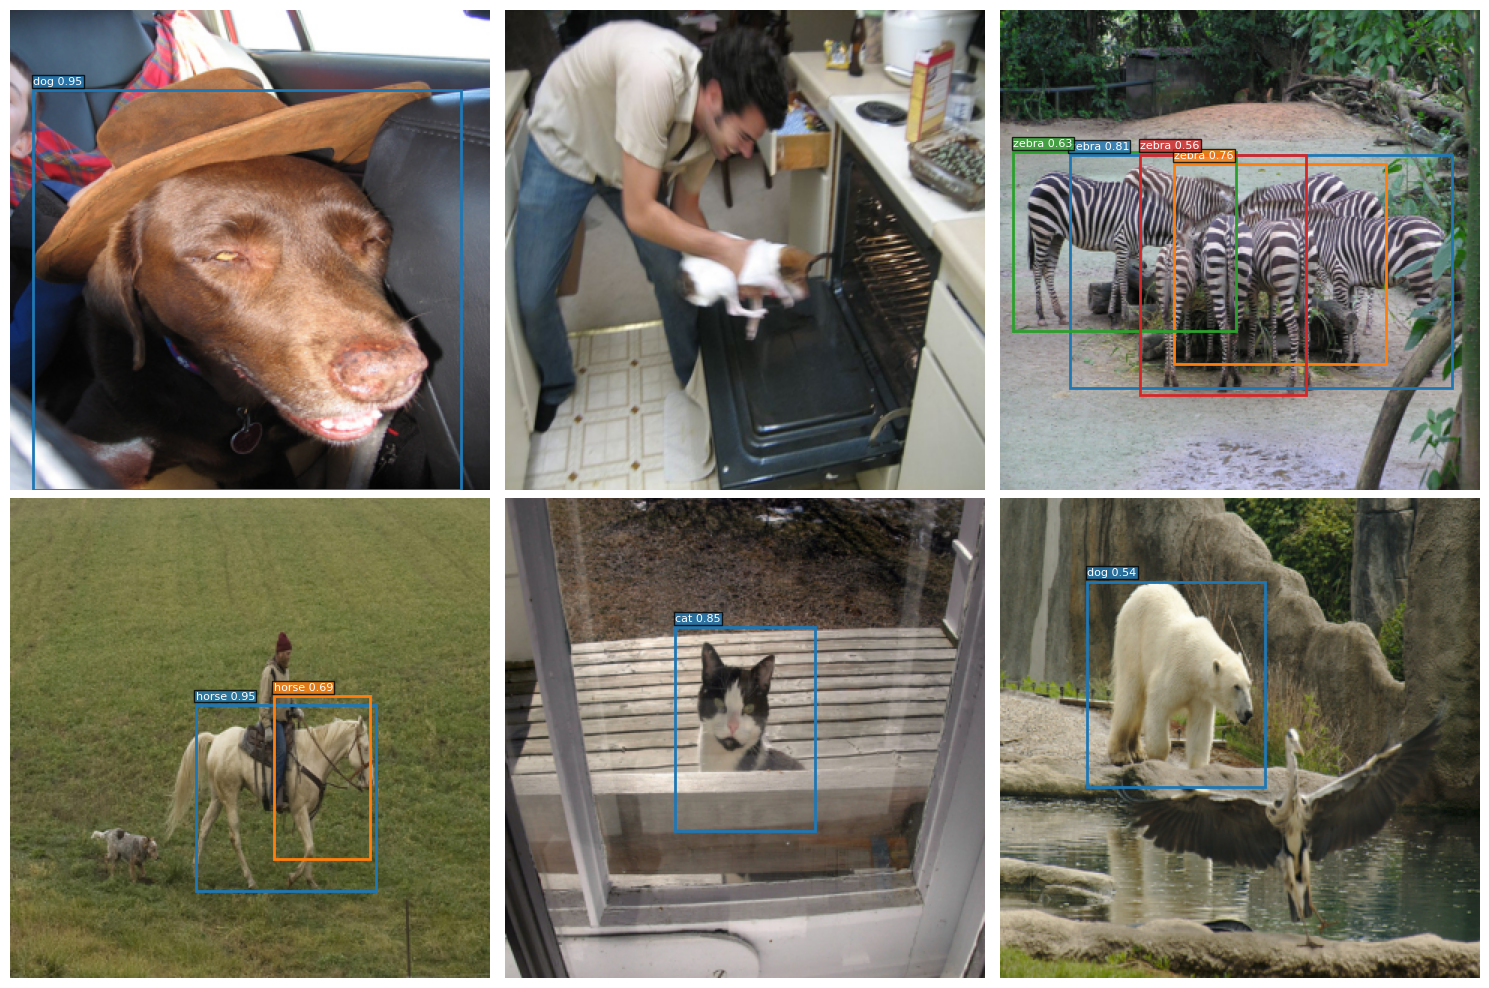

In [19]:
@torch.no_grad()
def predict_frcnn(model, image_pil, score_threshold=0.5, img_size=IMG_SIZE):
    """Run Faster R-CNN on a single PIL image. Returns CPU tensors + the resized image."""
    model.eval()
    img = image_pil.resize((img_size, img_size), Image.BILINEAR)
    x = T.ToTensor()(img).to(device)
    out = model([x])[0]
    keep = out["scores"] > score_threshold
    return {
        "image":  img,
        "boxes":  out["boxes"][keep].cpu(),
        "labels": out["labels"][keep].cpu(),
        "scores": out["scores"][keep].cpu(),
    }


def overlay_predictions(ax, pred, class_names):
    ax.imshow(pred["image"]); ax.axis("off")
    cmap = plt.get_cmap("tab10")
    for i, (box, lbl, score) in enumerate(zip(pred["boxes"], pred["labels"], pred["scores"])):
        color = cmap(i % 10)
        x1, y1, x2, y2 = box.tolist()
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                    linewidth=2, edgecolor=color, facecolor="none"))
        name = class_names[lbl.item() - 1]
        ax.text(x1, max(0, y1 - 4), f"{name} {score:.2f}",
                color="white", fontsize=8,
                bbox=dict(facecolor=color, alpha=0.8, pad=1))


# Show predictions on a few validation samples
sample_idx = random.sample(range(len(val_samples)), min(6, len(val_samples)))
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, idx in zip(axes.flat, sample_idx):
    pil = Image.open(val_samples[idx].filepath).convert("RGB")
    overlay_predictions(ax, predict_frcnn(frcnn, pil, score_threshold=0.5), COCO_CLASSES)
plt.tight_layout(); plt.show()

## 6. Summary and next steps

### What we did

1. Loaded **DINOv3-Small** (~21M parameters) from Hugging Face.
2. Did **off-the-shelf** similarity-based retrieval with **zero training**.
3. Trained a **frozen-backbone classifier** on a CIFAR-10 subset (only a linear layer was trained).
4. Trained a **Faster R-CNN** with a frozen DINOv3 backbone on a small COCO 2017 subset — RPN + box head learned, ViT untouched.

### Why "frozen backbone" works so well

DINOv3 was pretrained on **1.7 billion images** with self-supervision. Its features capture rich visual semantics that transfer to most natural-image tasks. Keeping the backbone frozen:

- Avoids the cost and data requirements of full fine-tuning.
- Preserves the general-purpose features (no catastrophic forgetting).
- Trains in minutes rather than days.

### Caveats of the single-scale ViT → Faster R-CNN setup

- Faster R-CNN was designed for FPN backbones (multi-scale). A single-scale ViT works but struggles with very small objects.
- A more accurate variant is **ViTDet** (Li et al., 2022), which builds an FPN-like structure from intermediate ViT blocks. The wrapper in this notebook is a simpler educational stand-in.
- 200 images and 3 epochs are nowhere near enough for production accuracy — they just demonstrate the wiring.

### Ideas for further exploration

- Add a mask head and turn this into **Mask R-CNN** for instance segmentation.
- Try **DINOv3-Base** (`facebook/dinov3-vitb16-pretrain-lvd1689m`) and compare AP / mAP.
- Add more COCO classes and more training samples; train longer.
- Replace the single-scale wrapper with a **ViTDet-style FPN** built from intermediate transformer blocks.
- **Unfreeze the last 1–2 transformer blocks** and fine-tune them at a low learning rate (e.g. `5e-5`).
- Swap in **DETR**-style heads instead of Faster R-CNN.

### Key takeaway

Modern vision foundation models like DINOv3 let you build strong classifiers and detectors **with very little task-specific data and compute**, by reusing high-quality pretrained features. The pattern `frozen backbone + small task head` is one of the most useful tools in modern computer vision.